In [35]:
import os
import numpy as np
import cv2
import requests
from io import BytesIO

import matplotlib.pyplot as plt
from PIL import Image

# Pasta onde todas as imagens geradas serão salvas
pasta_saida = os.path.join("output")
os.makedirs(pasta_saida, exist_ok=True)

def salvar_figura(fig, nome_arquivo):
    fig.savefig(os.path.join(pasta_saida, nome_arquivo), dpi=150, bbox_inches="tight")

# 1. Imagens de Input

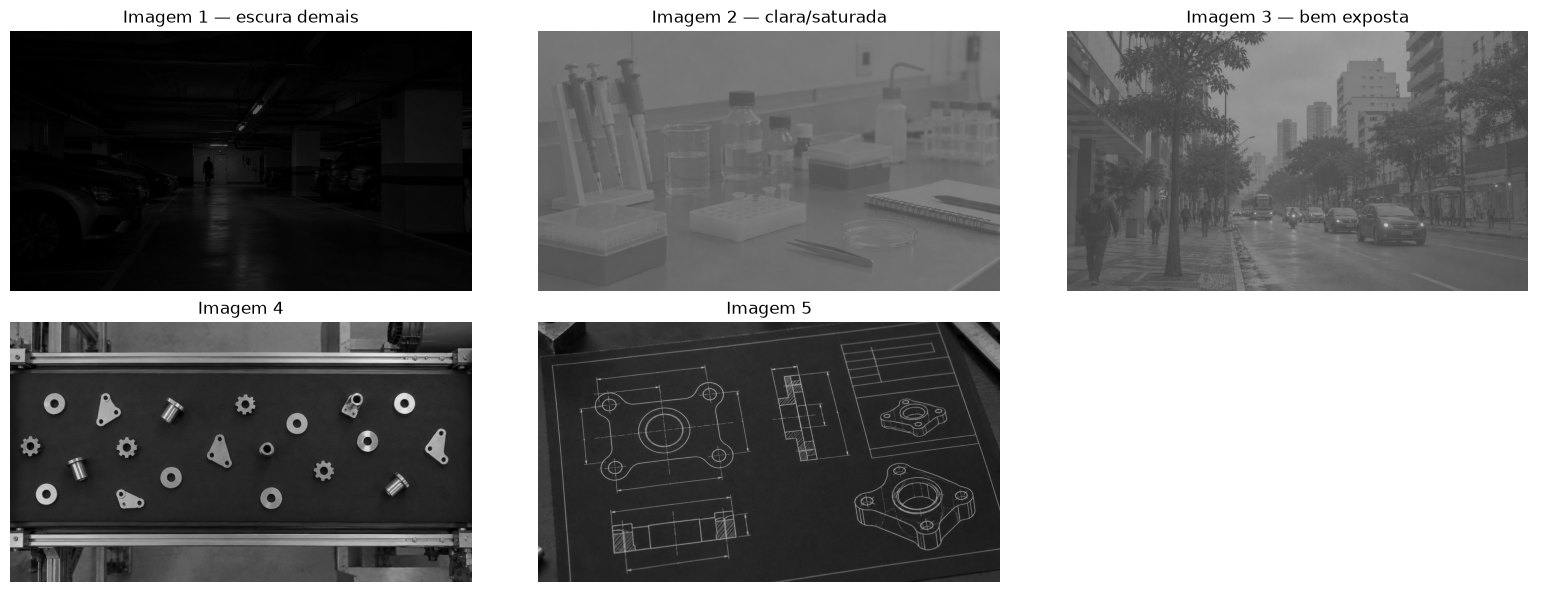

In [36]:
url_base = (
    "https://raw.githubusercontent.com/"
    "lianeheidemann/atividades-processamento-de-imagens/"
    "main/atividade/atividade-3/input/"
)

def carregar_imagem(nome_arquivo):
    resposta = requests.get(url_base + nome_arquivo)
    resposta.raise_for_status()
    return Image.open(BytesIO(resposta.content))

# Carregamento das cinco imagens
imagem_1 = carregar_imagem("imagem_01.png")
imagem_2 = carregar_imagem("imagem_02.png")
imagem_3 = carregar_imagem("imagem_03.png")
imagem_4 = carregar_imagem("imagem_04.png")
imagem_5 = carregar_imagem("imagem_05.png")

# Conversão para escala de cinza e array NumPy
imagem_cinza_1 = np.array(imagem_1.convert("L"), dtype=np.uint8)
imagem_cinza_2 = np.array(imagem_2.convert("L"), dtype=np.uint8)
imagem_cinza_3 = np.array(imagem_3.convert("L"), dtype=np.uint8)
imagem_cinza_4 = np.array(imagem_4.convert("L"), dtype=np.uint8)
imagem_cinza_5 = np.array(imagem_5.convert("L"), dtype=np.uint8)

imagens = [
    imagem_cinza_1,
    imagem_cinza_2,
    imagem_cinza_3,
    imagem_cinza_4,
    imagem_cinza_5,
]

titulos = [
    "Imagem 1 — escura demais",
    "Imagem 2 — clara/saturada",
    "Imagem 3 — bem exposta",
    "Imagem 4",
    "Imagem 5",
]

fig, eixos = plt.subplots(2, 3, figsize=(16, 6))
eixos = eixos.ravel()

for eixo, imagem, titulo in zip(eixos, imagens, titulos):
    eixo.imshow(imagem, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(titulo)
    eixo.axis("off")

eixos[5].axis("off")

plt.tight_layout()
salvar_figura(fig, "01_imagens_input.png")
plt.show()

# 2. Histogramas

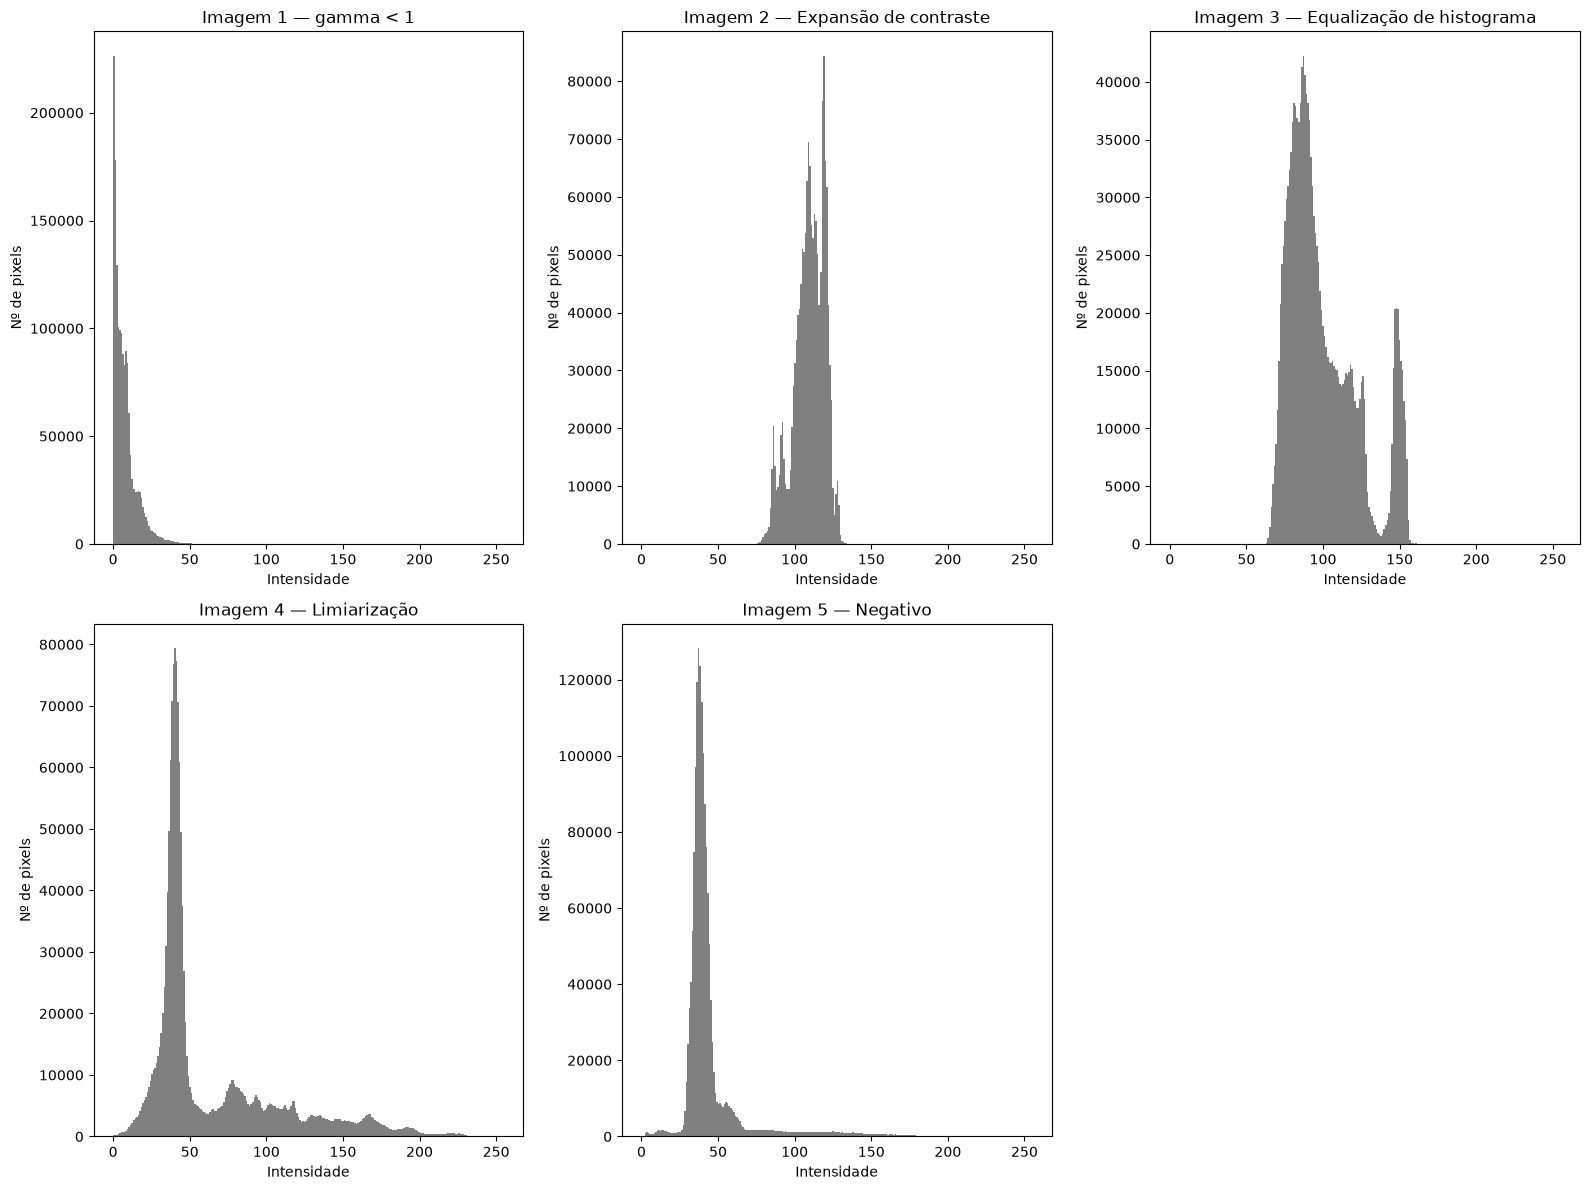

In [37]:
fig, eixos = plt.subplots(2, 3, figsize=(16, 12))
eixos = eixos.ravel()

imagens = [imagem_cinza_1, imagem_cinza_2, imagem_cinza_3, imagem_cinza_4, imagem_cinza_5]
titulos = [
    "Imagem 1 — gamma < 1",
    "Imagem 2 — Expansão de contraste",
    "Imagem 3 — Equalização de histograma",
    "Imagem 4 — Limiarização",
    "Imagem 5 — Negativo",
]

for eixo, imagem, titulo in zip(eixos, imagens, titulos):
    eixo.hist(imagem.ravel(), bins=256, range=(0, 255), color="gray")
    eixo.set_title(titulo)
    eixo.set_xlabel("Intensidade")
    eixo.set_ylabel("Nº de pixels")

eixos[5].axis("off")

plt.tight_layout()
salvar_figura(fig, "02_histogramas_originais.png")
plt.show()

# 3. Tratamento de Imagens

## Imagem 01 — Correção gama

A imagem está subexposta. A correção gama clareia principalmente os tons escuros, revelando carros, colunas e o piso sem alterar tudo de forma linear. Comece com gamma = 0.4 ou 0.5.

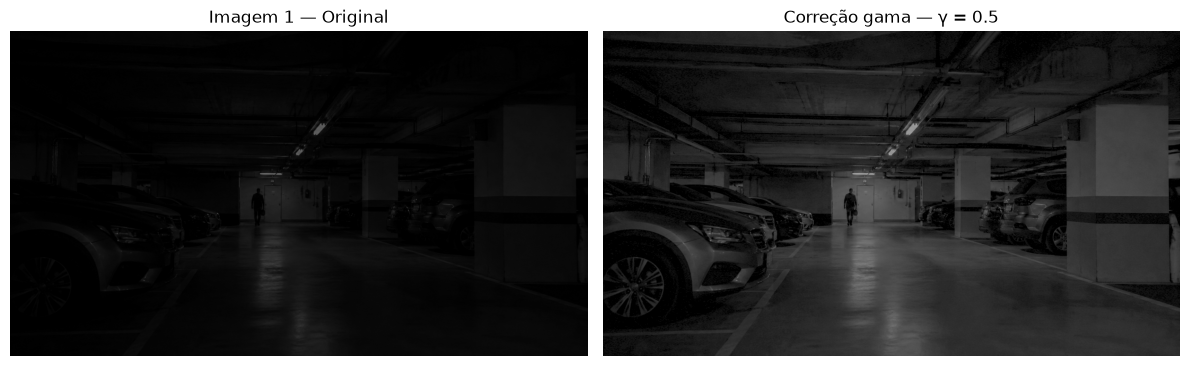

In [38]:
gamma = 0.5  # gamma < 1 clareia a imagem

imagem_normalizada = imagem_cinza_1.astype(np.float32) / 255.0

imagem_1_tratada = np.power(
    imagem_normalizada,
    gamma
)

imagem_1_tratada = np.clip(
    imagem_1_tratada * 255,
    0,
    255
).astype(np.uint8)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_cinza_1, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Imagem 1 — Original")
eixos[0].axis("off")

eixos[1].imshow(imagem_1_tratada, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title(f"Correção gama — γ = {gamma}")
eixos[1].axis("off")

plt.tight_layout()
salvar_figura(fig, "03_imagem_01_correcao_gama.png")
plt.show()

A correção gama foi escolhida porque a imagem apresentava baixa luminosidade e concentração de pixels nas intensidades mais escuras. A utilização de γ = 0,5 deslocou os níveis de cinza para intensidades mais altas, revelando detalhes dos carros, das colunas e do piso da garagem. O tratamento melhorou a visibilidade da cena sem aplicar o mesmo aumento a todos os pixels, preservando melhor as diferenças de tonalidade.


## Imagem 2 — Expansão de contraste

Os níveis de cinza estão concentrados em uma faixa estreita e clara, deixando a imagem “lavada”. A expansão redistribui essa faixa para aumentar a separação entre objetos e fundo.

Limite inferior: 86.00
Limite superior: 126.00


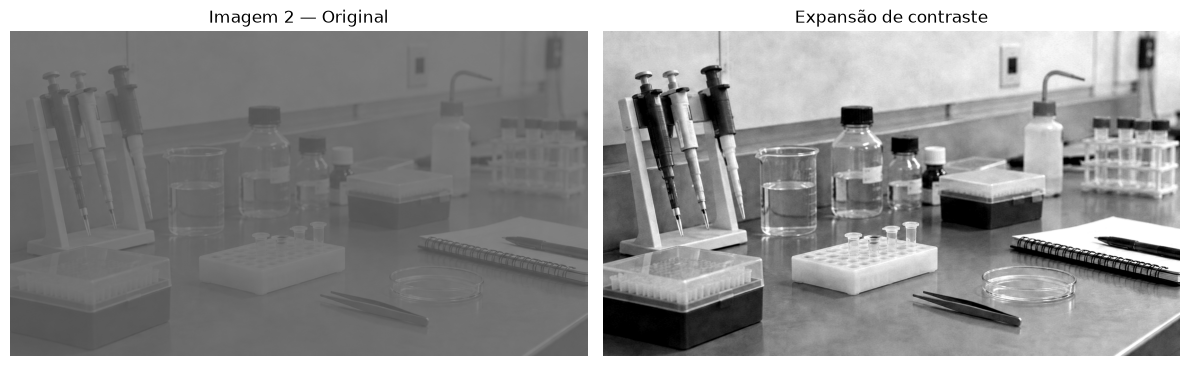

In [39]:
# Limites calculados por percentis para ignorar pixels extremos
limite_inferior = np.percentile(imagem_cinza_2, 2)
limite_superior = np.percentile(imagem_cinza_2, 98)

if limite_superior == limite_inferior:
    resultado_contraste = imagem_cinza_2.copy()
else:
    resultado_contraste = (
        imagem_cinza_2.astype(np.float32) - limite_inferior
    ) * (
        255.0 / (limite_superior - limite_inferior)
    )

    resultado_contraste = np.clip(
        resultado_contraste,
        0,
        255
    ).astype(np.uint8)

print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_cinza_2, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Imagem 2 — Original")
eixos[0].axis("off")

eixos[1].imshow(resultado_contraste, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title("Expansão de contraste")
eixos[1].axis("off")

plt.tight_layout()
salvar_figura(fig, "04_imagem_02_expansao_contraste.png")
plt.show()

A expansão de contraste foi aplicada porque os níveis de cinza estavam concentrados em uma faixa limitada, produzindo uma imagem clara e com pouca diferenciação entre os objetos. Os percentis 2 e 98 foram utilizados como limites inferior e superior para reduzir a influência de pixels extremos. Após o tratamento, as intensidades passaram a ocupar uma faixa maior, aumentando a separação visual entre os instrumentos, os recipientes e o fundo do laboratório.


## Imagem 3 — Equalização do histograma

A cena apresenta contraste global baixo, com muitos tons médios semelhantes. A equalização distribui melhor as intensidades e evidencia prédios, árvores, veículos e pedestres.

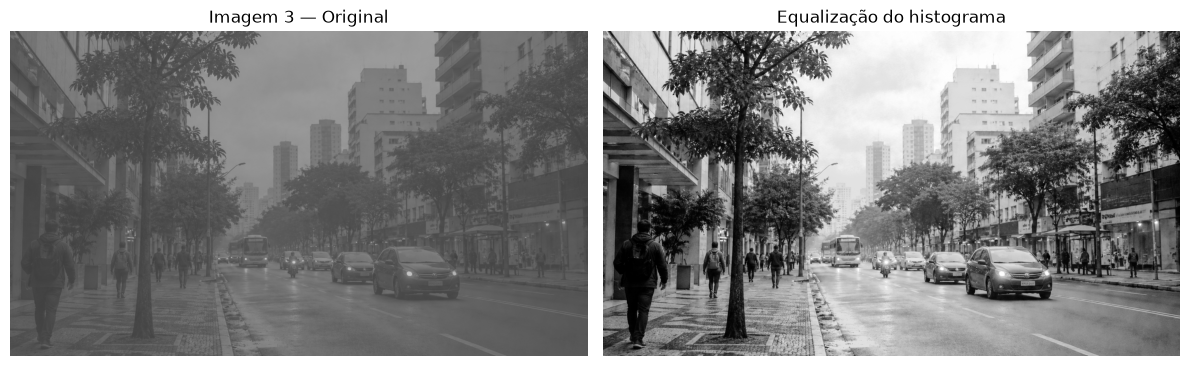

In [40]:
# Calcula o histograma da imagem
histograma = np.bincount(
    imagem_cinza_3.ravel(),
    minlength=256
)

# Calcula a distribuição acumulada
distribuicao_acumulada = histograma.cumsum()

# Obtém somente os valores acumulados diferentes de zero
valores_validos = distribuicao_acumulada[
    distribuicao_acumulada > 0
]

cdf_minimo = valores_validos[0]
total_pixels = imagem_cinza_3.size

# Cria a tabela de transformação
tabela_equalizacao = (
    (distribuicao_acumulada - cdf_minimo)
    / (total_pixels - cdf_minimo)
) * 255

tabela_equalizacao = np.clip(
    tabela_equalizacao,
    0,
    255
).astype(np.uint8)

# Aplica a transformação
resultado_equalizacao = tabela_equalizacao[imagem_cinza_3]

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_cinza_3, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Imagem 3 — Original")
eixos[0].axis("off")

eixos[1].imshow(resultado_equalizacao, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title("Equalização do histograma")
eixos[1].axis("off")

plt.tight_layout()
salvar_figura(fig, "05_imagem_03_equalizacao_histograma.png")
plt.show()

A equalização do histograma foi utilizada para melhorar o contraste global da imagem, que apresentava predominância de tons médios e pouca diferenciação entre algumas regiões. O tratamento redistribuiu os níveis de intensidade ao longo da escala de cinza, tornando mais perceptíveis os detalhes dos prédios, das árvores, dos veículos e dos pedestres. O histograma final mais distribuído confirma o aumento do contraste da cena.


## Imagem 4 — Limiarização

Existe uma separação clara entre as peças metálicas claras e a esteira escura. A limiarização transforma a imagem em binária, sendo útil para segmentar, contar e localizar as peças.

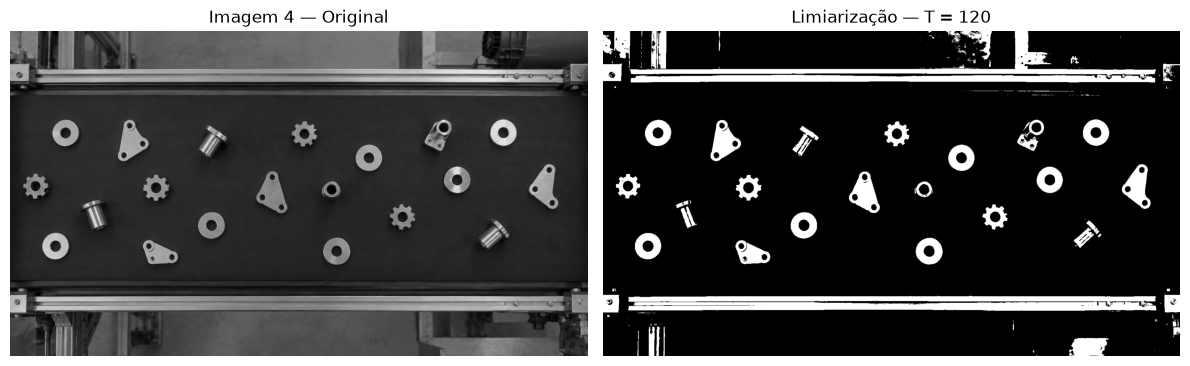

In [41]:
# Limiar adequado para separar as peças metálicas do fundo escuro
limiar = 120

resultado_limiarizacao = np.where(
    imagem_cinza_4 >= limiar,
    255,
    0
).astype(np.uint8)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_cinza_4, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Imagem 4 — Original")
eixos[0].axis("off")

eixos[1].imshow(
    resultado_limiarizacao,
    cmap="gray",
    vmin=0,
    vmax=255
)
eixos[1].set_title(f"Limiarização — T = {limiar}")
eixos[1].axis("off")

plt.tight_layout()
salvar_figura(fig, "06_imagem_04_limiarizacao.png")
plt.show()

A limiarização foi escolhida devido à diferença de intensidade entre as peças metálicas claras e a esteira escura. Com o limiar definido em 120, os pixels com intensidade igual ou superior a esse valor foram convertidos em branco, enquanto os demais foram convertidos em preto. O resultado facilitou a separação entre os objetos e o fundo, sendo adequado para aplicações como identificação, localização e contagem das peças.


## Imagem 5 — Negativo

Como o desenho possui linhas claras sobre fundo escuro, o negativo produz linhas escuras sobre fundo claro, facilitando leitura, impressão e análise das linhas.

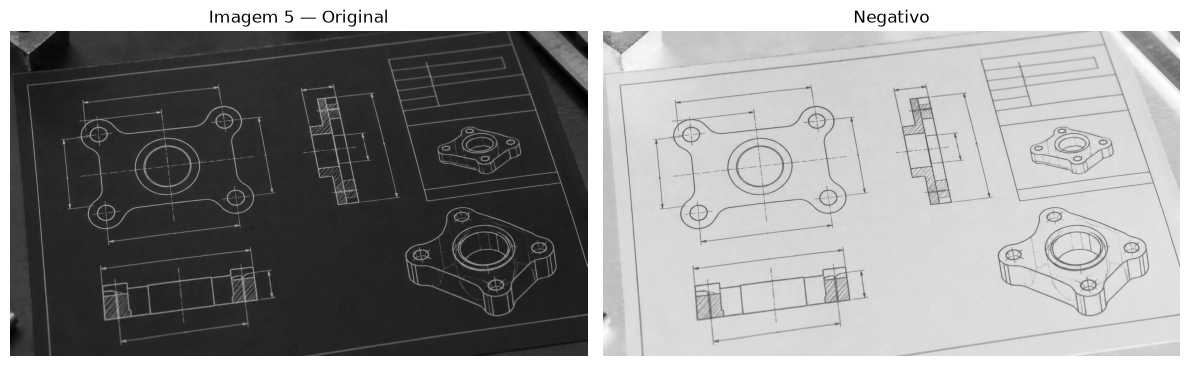

In [42]:
resultado_negativo = 255 - imagem_cinza_5

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(imagem_cinza_5, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Imagem 5 — Original")
eixos[0].axis("off")

eixos[1].imshow(resultado_negativo, cmap="gray", vmin=0, vmax=255)
eixos[1].set_title("Negativo")
eixos[1].axis("off")

plt.tight_layout()
salvar_figura(fig, "07_imagem_05_negativo.png")
plt.show()

A transformação negativa foi aplicada porque o desenho técnico possui linhas claras sobre um fundo predominantemente escuro. A inversão dos níveis de cinza transformou as regiões escuras em claras e as linhas claras em escuras, produzindo uma representação semelhante à de um desenho impresso em papel. O resultado facilita a leitura das linhas, das medidas e dos detalhes geométricos da peça.


# 4. Histograma das imagens tratadas

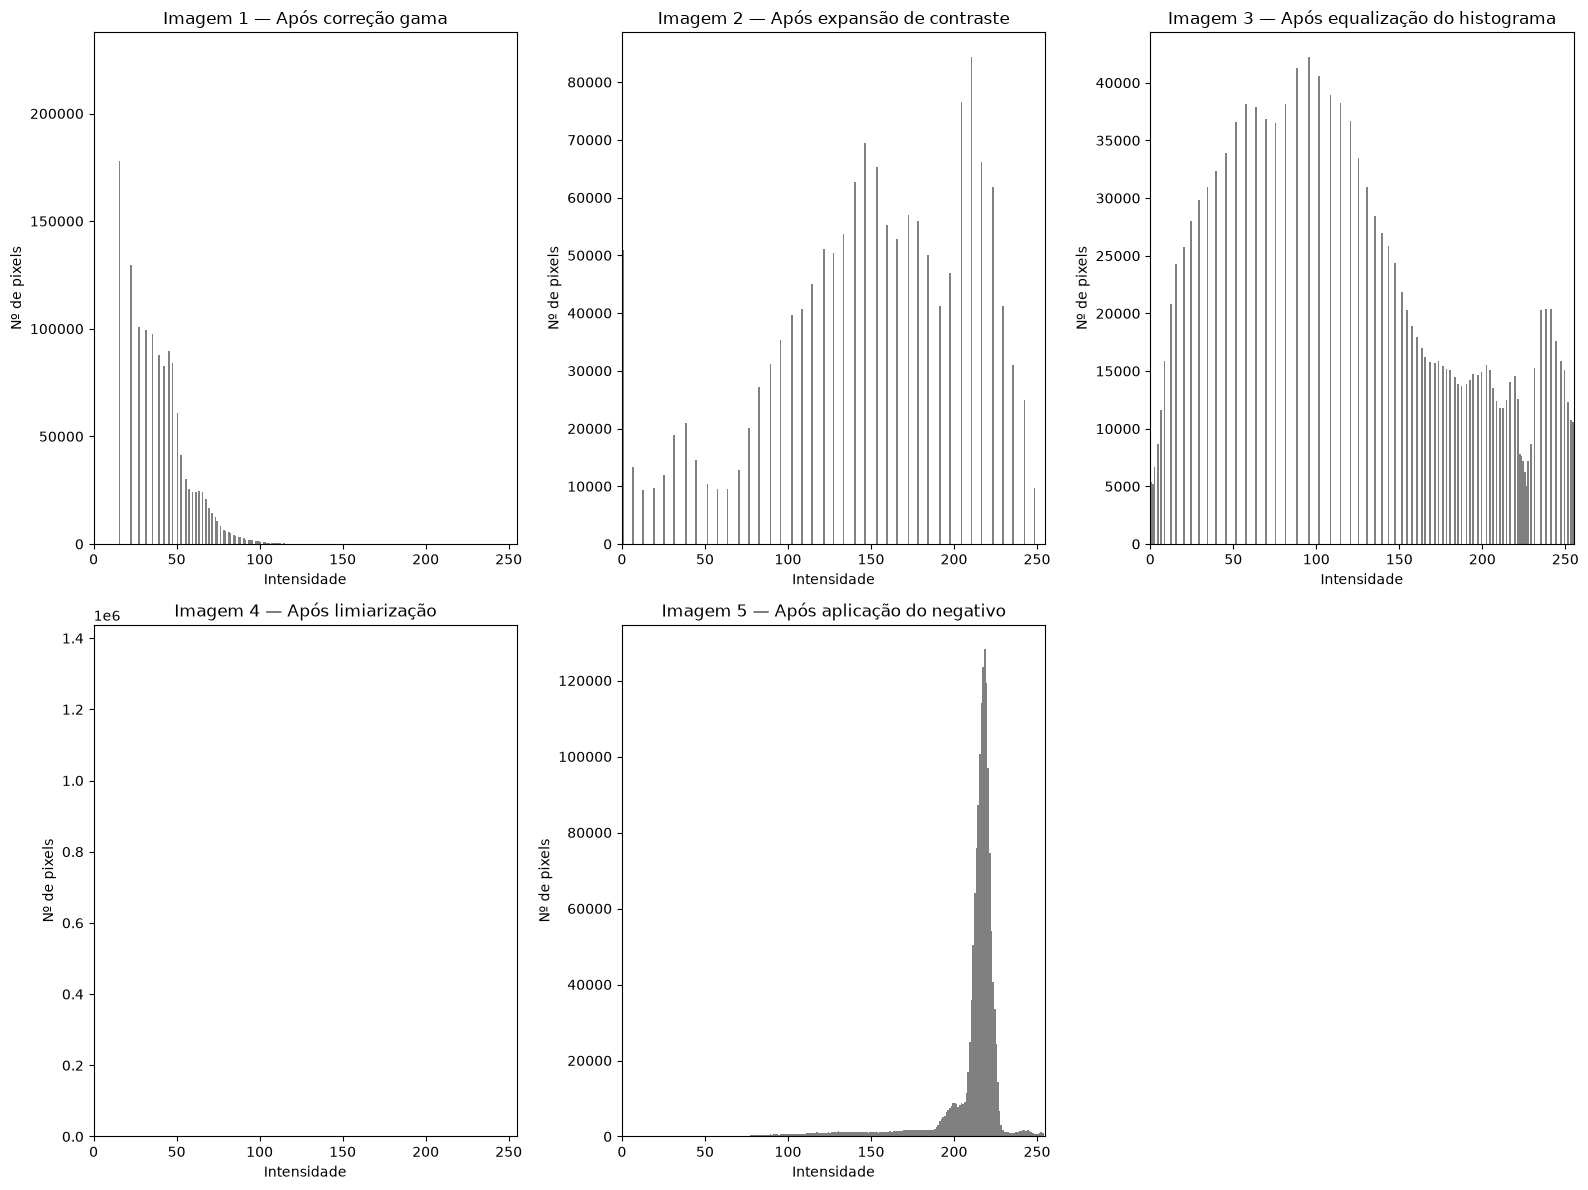

In [43]:
fig, eixos = plt.subplots(2, 3, figsize=(16, 12))
eixos = eixos.ravel()

# Resultados produzidos pelas células de tratamento
imagens_tratadas = [
    imagem_1_tratada,
    resultado_contraste,
    resultado_equalizacao,
    resultado_limiarizacao,
    resultado_negativo,
]

titulos = [
    "Imagem 1 — Após correção gama",
    "Imagem 2 — Após expansão de contraste",
    "Imagem 3 — Após equalização do histograma",
    "Imagem 4 — Após limiarização",
    "Imagem 5 — Após aplicação do negativo",
]

for eixo, imagem, titulo in zip(
    eixos,
    imagens_tratadas,
    titulos
):
    eixo.hist(
        imagem.ravel(),
        bins=256,
        range=(0, 256),
        color="gray"
    )

    eixo.set_title(titulo)
    eixo.set_xlabel("Intensidade")
    eixo.set_ylabel("Nº de pixels")
    eixo.set_xlim(0, 255)

# Oculta a sexta posição, pois existem apenas cinco imagens
eixos[5].axis("off")

plt.tight_layout()
salvar_figura(fig, "08_histogramas_tratadas.png")
plt.show()

# 5. Comparação antes/depois — imagem, imagem tratada e histogramas

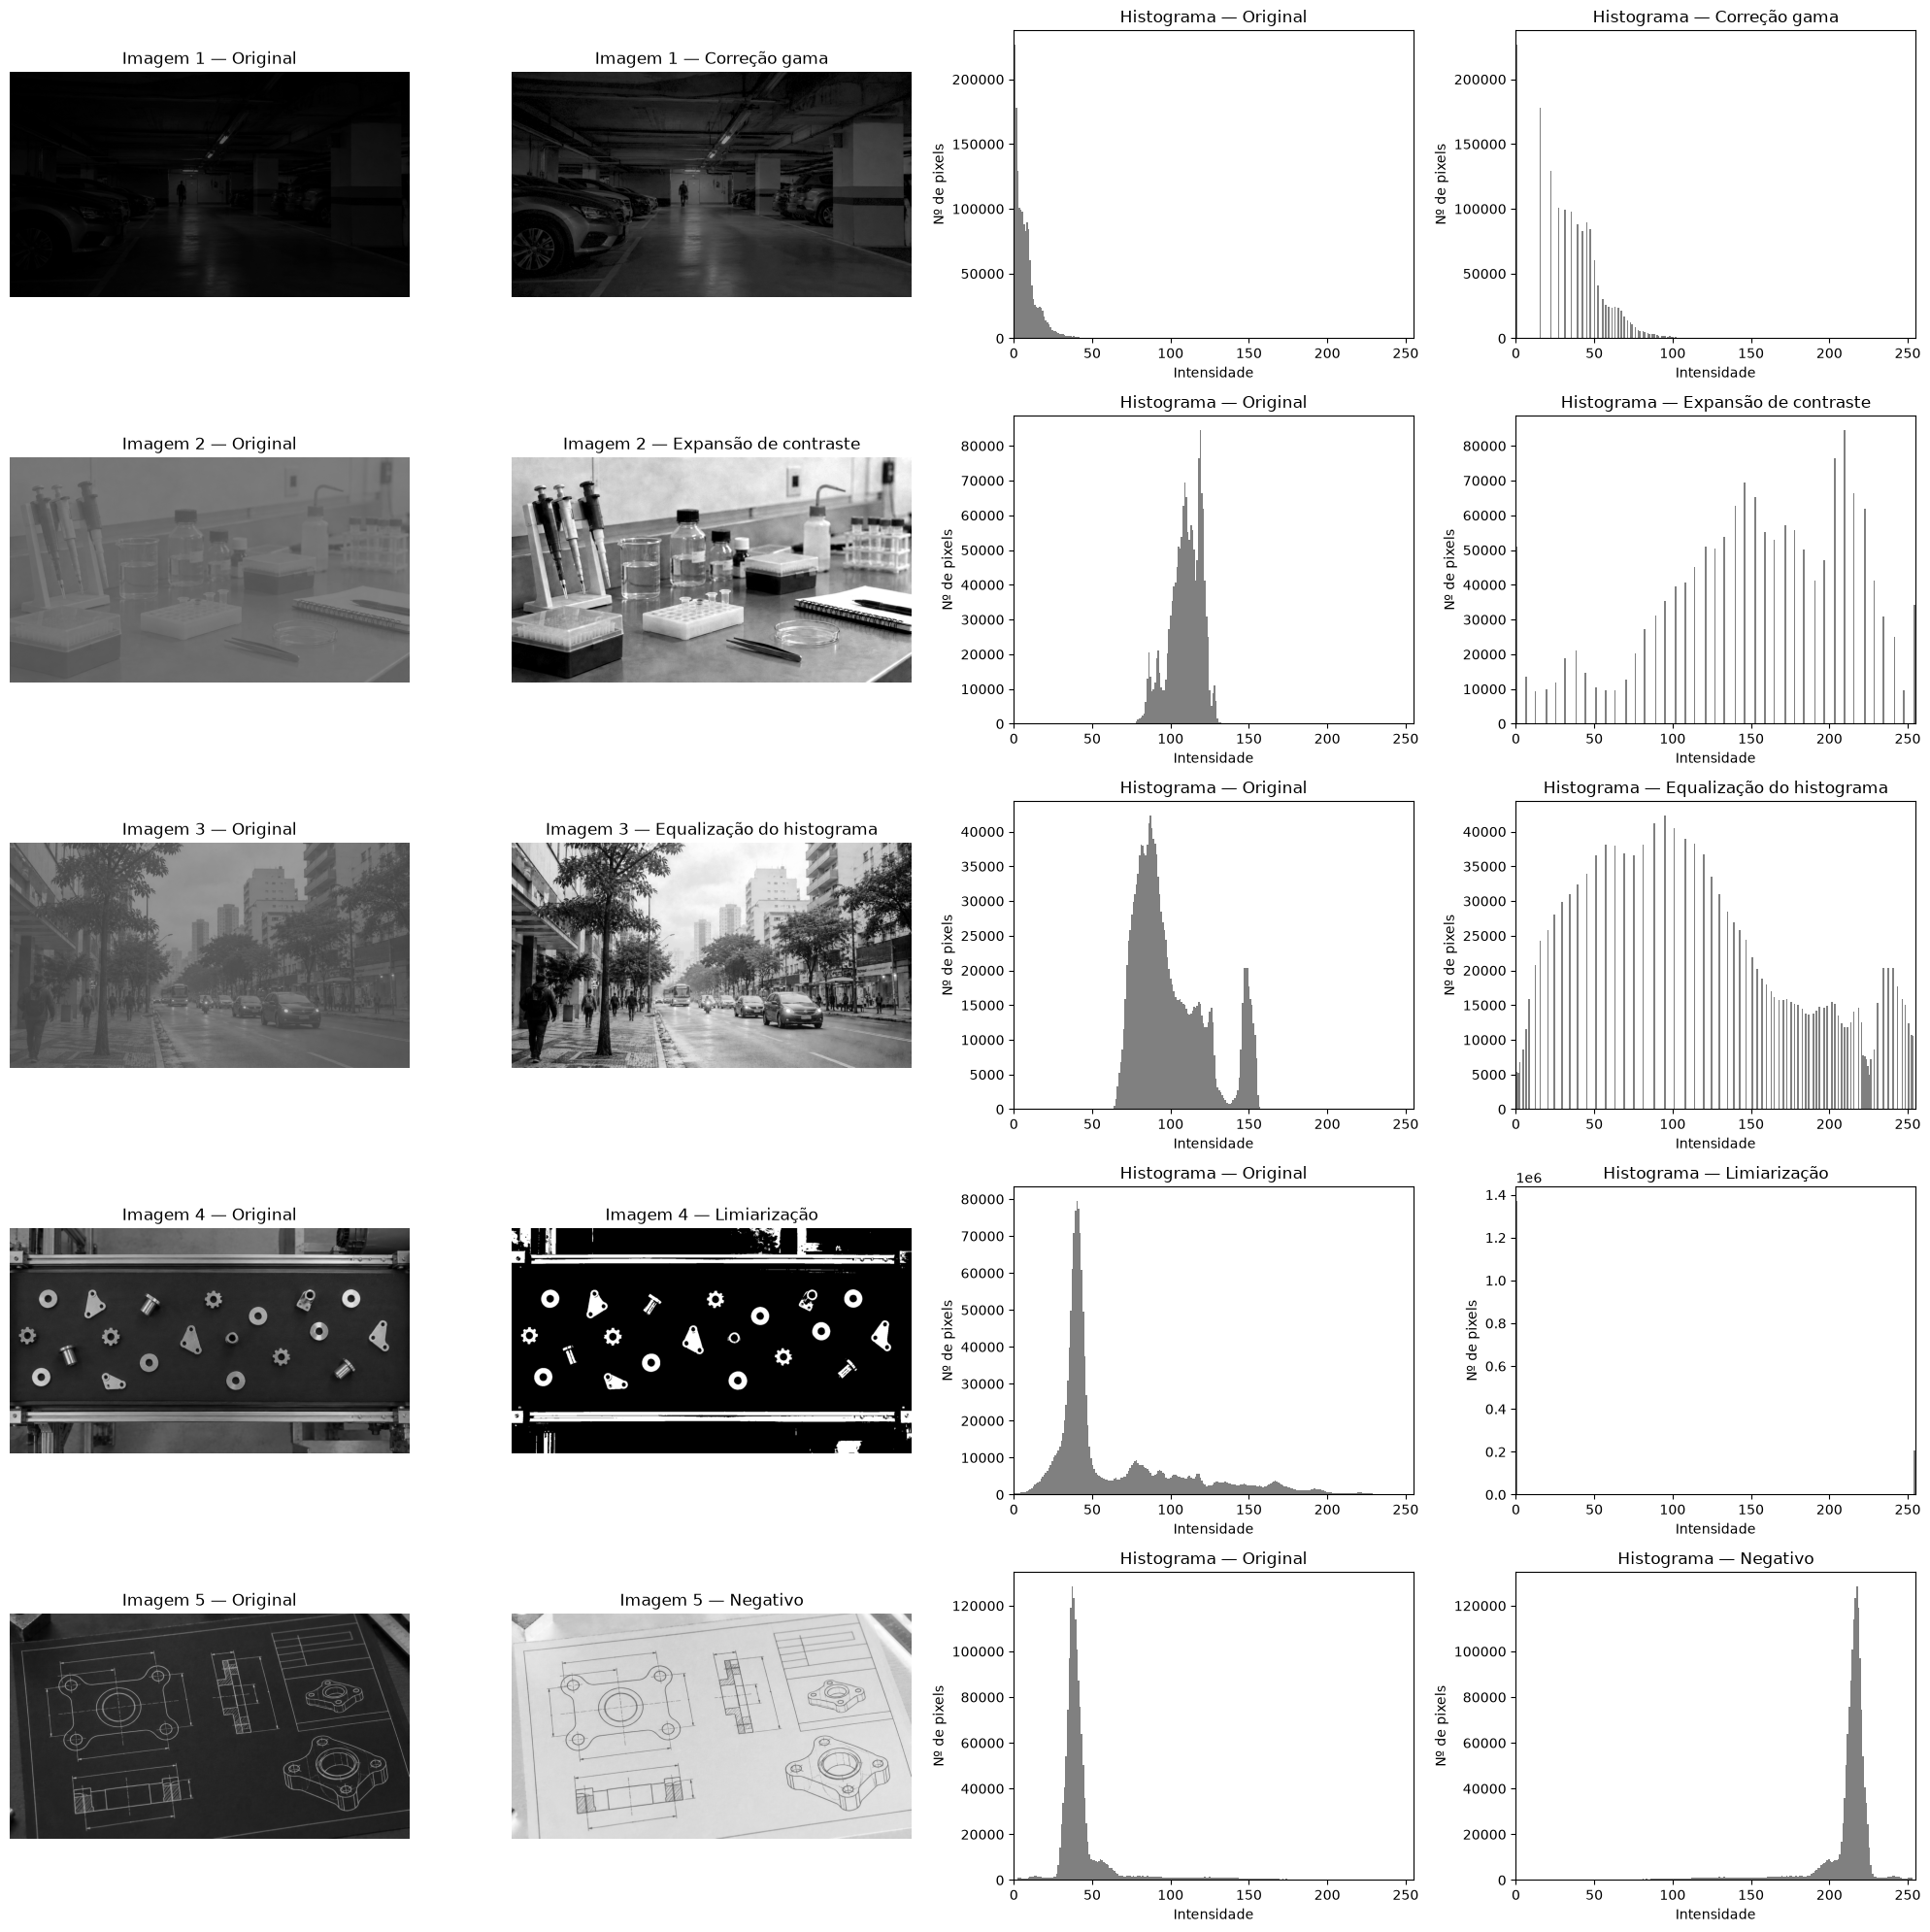

In [44]:
imagens_originais = [
    imagem_cinza_1,
    imagem_cinza_2,
    imagem_cinza_3,
    imagem_cinza_4,
    imagem_cinza_5,
]

imagens_tratadas = [
    imagem_1_tratada,
    resultado_contraste,
    resultado_equalizacao,
    resultado_limiarizacao,
    resultado_negativo,
]

nomes_tratamentos = [
    "Correção gama",
    "Expansão de contraste",
    "Equalização do histograma",
    "Limiarização",
    "Negativo",
]

n_imagens = len(imagens_originais)

fig, eixos = plt.subplots(n_imagens, 4, figsize=(20, 4 * n_imagens))

for i, (original, tratada, nome) in enumerate(
    zip(imagens_originais, imagens_tratadas, nomes_tratamentos)
):
    eixo_img_original, eixo_img_tratada, eixo_hist_original, eixo_hist_tratada = eixos[i]

    eixo_img_original.imshow(original, cmap="gray", vmin=0, vmax=255)
    eixo_img_original.set_title(f"Imagem {i + 1} — Original")
    eixo_img_original.axis("off")

    eixo_img_tratada.imshow(tratada, cmap="gray", vmin=0, vmax=255)
    eixo_img_tratada.set_title(f"Imagem {i + 1} — {nome}")
    eixo_img_tratada.axis("off")

    eixo_hist_original.hist(original.ravel(), bins=256, range=(0, 255), color="gray")
    eixo_hist_original.set_title("Histograma — Original")
    eixo_hist_original.set_xlabel("Intensidade")
    eixo_hist_original.set_ylabel("Nº de pixels")
    eixo_hist_original.set_xlim(0, 255)

    eixo_hist_tratada.hist(tratada.ravel(), bins=256, range=(0, 255), color="gray")
    eixo_hist_tratada.set_title(f"Histograma — {nome}")
    eixo_hist_tratada.set_xlabel("Intensidade")
    eixo_hist_tratada.set_ylabel("Nº de pixels")
    eixo_hist_tratada.set_xlim(0, 255)

plt.tight_layout()
salvar_figura(fig, "09_comparacao_antes_depois.png")
plt.show()